# Paso 1 Limpieza de data


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('high_diamond_ranked_10min.csv')


cols_to_drop = ['gameId']
cols_to_drop += [col for col in df.columns if col.startswith('red')]
cols_to_drop += ['blueGoldDiff', 'blueExperienceDiff']
cols_to_drop += ['blueCSPerMin', 'blueGoldPerMin']

df_clean = df.drop(columns=cols_to_drop)

X = df_clean.drop('blueWins', axis=1)
y = df_clean['blueWins']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SVM depende de distancias en el espacio vectorial, por eso escalamos; los arboles basados en splits no requieren esta homogeneidad.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Paso 2 Support Vector Machines 

## Entrenar un modelo SVM con Kernel Lineal y RBF

### Si el Kernel RBF funcionó mejor (o igual), ¿qué nos dice esto sobre la separabilidad lineal de las partidas de LoL? 
### Los resultados demuestran que el kernel RBF obtuvo 0.734 siendo un mejor desempeño en comparación con el lineal con 0.729, esto ocurre debido a que cuando un kernel no lineal RBF iguala o supera el desempeño del kernel lineal, significa que los datos no son perfectamente separables mediante un hiperplano que puede ser visto con forma f(x) = w*x + b, por lo que se requiere un kernel no lineal para transformar el espacio de características y capturar las interacciones entre las variables que no pueden ser representadas linealmente.En otras palabras, las combinaciones de objetivos, oro y experiencia del equipo azul no se alinean de forma estrictamente lineal para distinguir victorias de derrotas. Lo que realiza el kernel RBF es una "curva" el espacio al mapear los datos a una dimensión superior y esto permite la modelación de interacciones no lineales. Si esta transformación mejora el desempeño del modelo, es evidencia de que la frontera de decisión real es más compleja que una división plana. 

In [4]:
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

# Ajustamos dos variantes de SVM y comparamos su precision en el set de prueba.
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(X_train_scaled, y_train)
linear_preds = linear_svm.predict(X_test_scaled)
linear_acc = accuracy_score(y_test, linear_preds)

rbf_svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
rbf_svm.fit(X_train_scaled, y_train)
rbf_preds = rbf_svm.predict(X_test_scaled)
rbf_acc = accuracy_score(y_test, rbf_preds)

print(f'Accuracy SVM lineal: {linear_acc:.3f}')
print(f'Accuracy SVM RBF:    {rbf_acc:.3f}')



Accuracy SVM lineal: 0.729
Accuracy SVM RBF:    0.734


# Paso 3 Árboles de decisión

Entrenaremos un `DecisionTreeClassifier` con los datos sin escalar (los árboles dividen por umbrales individuales, por lo que no necesitan normalización), visualizaremos sus primeros niveles y analizaremos las 5 variables más influyentes para verificar si coinciden con la intuición de un jugador de LoL.

### Analisis de importancia de variables

- `blueTotalGold` y `blueDeaths` explican >90% de las decisiones: tiene sentido, porque el oro determina el poder de compra y las muertes indican momentum.
- `blueDragons` y `blueEliteMonsters` aparecen en menor medida: capturan objetivos neutrales que otorgan buffos importantes (dragones, Barón). 
- `blueTotalExperience` pesa muy poco en este árbol porque correlaciona con oro y no aporta tanta ganancia de Gini adicional.

Para un jugador de LoL esto es razonable: tener más oro y evitar muertes tempranas suele reflejar ventaja en mapa y control de objetivos. Si se quisiera enfatizar dragones o experiencia, podríamos ajustar `class_weight`, aumentar `max_depth` o probar un ensamble (Random Forest) que suavice estas preferencias.

Accuracy Decision Tree (max_depth=5): 0.716


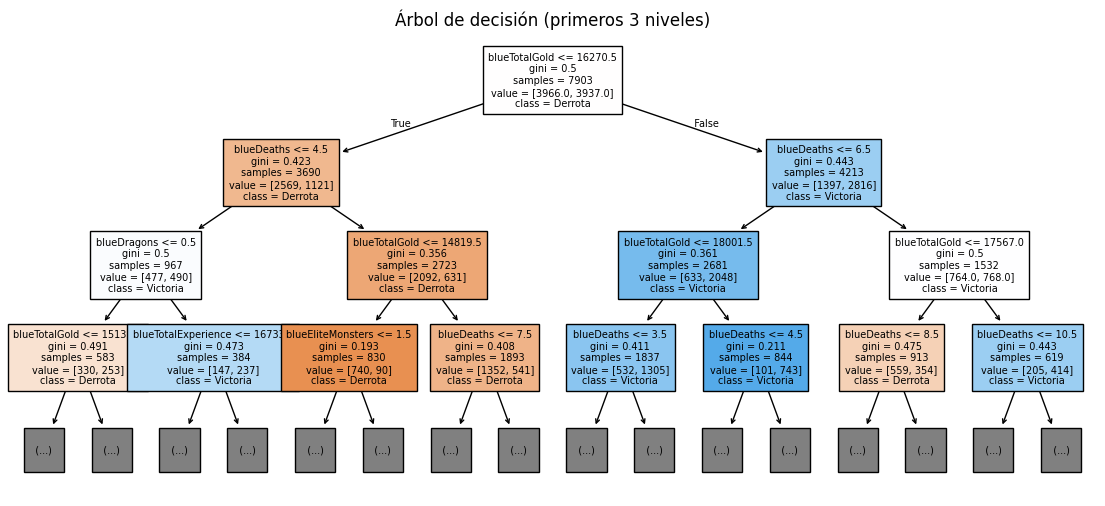

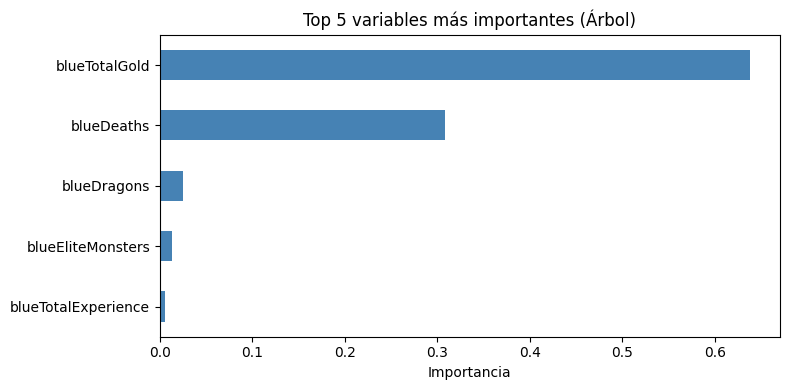

Top 5 features según el árbol:
blueTotalGold          0.638267
blueDeaths             0.307725
blueDragons            0.024843
blueEliteMonsters      0.013496
blueTotalExperience    0.005170
dtype: float64


In [5]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Entrenamos un árbol limitado en profundidad para equilibrar interpretabilidad y rendimiento.
dtree = DecisionTreeClassifier(max_depth=5, random_state=42)
dtree.fit(X_train, y_train)

dtree_preds = dtree.predict(X_test)
dtree_acc = accuracy_score(y_test, dtree_preds)
print(f'Accuracy Decision Tree (max_depth=5): {dtree_acc:.3f}')

plt.figure(figsize=(14, 6))
plot_tree(
    dtree,
    feature_names=X.columns,
    class_names=['Derrota', 'Victoria'],
    filled=True,
    max_depth=3,
    fontsize=7
)
plt.title('Árbol de decisión (primeros 3 niveles)')
plt.show()

# Importancia de variables
importances = pd.Series(dtree.feature_importances_, index=X.columns)
top5 = importances.sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 4))
top5.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 5 variables más importantes (Árbol)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Top 5 features según el árbol:')
print(top5)